# 12 — Final Test Error Analysis

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook analyzes the frozen final Random Forest on the already reported test split. It explains failure modes and weak slices; it does not tune, retrain, or replace the model after seeing test results.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_features" / "test.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError("Test features were not found. Run notebook 07 first.")

PROJECT_ROOT = find_project_root()
FEATURE_FILE = PROJECT_ROOT / "data" / "processed" / "m5_foods_features" / "test.parquet"
REPORT_DIR = PROJECT_ROOT / "reports"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
REPORT_DIR.mkdir(exist_ok=True)

## 1. Restore the frozen model and test rows

The run ID comes from the committed final-run summary. No fitting occurs here.

In [2]:
numeric_features = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4",
    "sales_roll_mean_8", "sales_roll_std_8",
    "zero_weeks_last_4", "sell_price_mean", "price_lag_1",
    "price_change_pct", "year", "month", "week_of_year",
    "quarter", "event_days", "has_event", "snap_days", "has_snap",
]
target = "weekly_units_sold"
metadata_columns = ["week_start", "item_id", "dept_id", "store_id", "dataset_split"]
test = pd.read_parquet(FEATURE_FILE, columns=metadata_columns + numeric_features + [target])
summary = pd.read_csv(REPORT_DIR / "mlflow_final_model_run.csv").iloc[0]
mlflow.set_tracking_uri("sqlite:///" + MLFLOW_DB.as_posix())
model = mlflow.sklearn.load_model(f"runs:/{summary['run_id']}/model")
predictions = model.predict(test[numeric_features].astype("float32"))

results = test[metadata_columns + [target]].copy()
results["prediction"] = predictions
results["residual"] = results["prediction"] - results[target]
results["absolute_error"] = results["residual"].abs()
results["squared_error"] = results["residual"].pow(2)
print("Analyzed test rows:", f"{len(results):,}")

Analyzed test rows: 57,480


## 2. Overall error distribution

MAE gives the average error, while percentiles show how large the difficult tail becomes. A negative mean residual means the model underpredicts on average.

In [3]:
error_summary = pd.DataFrame([{
    "rows": len(results),
    "mae": results["absolute_error"].mean(),
    "rmse": np.sqrt(results["squared_error"].mean()),
    "median_absolute_error": results["absolute_error"].median(),
    "p90_absolute_error": results["absolute_error"].quantile(0.90),
    "p95_absolute_error": results["absolute_error"].quantile(0.95),
    "p99_absolute_error": results["absolute_error"].quantile(0.99),
    "maximum_absolute_error": results["absolute_error"].max(),
    "mean_error": results["residual"].mean(),
    "within_1_unit_pct": 100 * results["absolute_error"].le(1).mean(),
    "within_5_units_pct": 100 * results["absolute_error"].le(5).mean(),
}])
display(error_summary.T)

,0
rows,"57,480.000"
mae,4.418
rmse,9.133
median_absolute_error,2.345
p90_absolute_error,9.434
p95_absolute_error,14.755
p99_absolute_error,36.103
maximum_absolute_error,275.224
mean_error,-0.403
within_1_unit_pct,24.276


## 3. Demand-level failure modes

Demand bands are defined from actual test demand only for post-model analysis. They are not features and do not change the model.

In [4]:
results["demand_band"] = pd.cut(
    results[target],
    bins=[-0.01, 0, 5, 20, np.inf],
    labels=["zero", "low_1_to_5", "medium_6_to_20", "high_21_plus"],
)

def slice_metrics(data, group_column):
    return data.groupby(group_column, observed=True).agg(
        rows=(target, "size"),
        actual_mean=(target, "mean"),
        predicted_mean=("prediction", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda values: np.sqrt(values.mean())),
        mean_error=("residual", "mean"),
    ).reset_index()

demand_band_metrics = slice_metrics(results, "demand_band")
store_metrics = slice_metrics(results, "store_id")
department_metrics = slice_metrics(results, "dept_id")
week_metrics = slice_metrics(results, "week_start")
display(demand_band_metrics)
display(store_metrics.sort_values("mae"))
display(department_metrics.sort_values("mae"))

,demand_band,rows,actual_mean,predicted_mean,mae,rmse,mean_error
0,zero,4960,0.000,2.739,2.739,4.766,2.739
1,low_1_to_5,19578,2.965,4.319,2.014,3.325,1.354
2,medium_6_to_20,23245,10.830,10.235,3.500,4.866,-0.594
3,high_21_plus,9697,53.904,48.803,12.331,20.093,-5.101


,store_id,rows,actual_mean,predicted_mean,mae,rmse,mean_error
3,CA_4,5748,8.984,8.755,3.090,4.980,-0.229
4,TX_1,5748,10.846,10.762,3.671,7.438,-0.084
5,TX_2,5748,13.263,13.022,3.915,7.501,-0.241
7,WI_1,5748,13.732,13.375,3.968,6.646,-0.357
6,TX_3,5748,13.414,12.837,4.152,8.408,-0.577
9,WI_3,5748,14.644,14.322,4.240,8.258,-0.323
1,CA_2,5748,15.174,14.284,4.479,7.617,-0.890
0,CA_1,5748,15.803,15.174,4.766,8.946,-0.628
2,CA_3,5748,19.114,18.999,5.397,11.102,-0.116
8,WI_2,5748,19.856,19.267,6.502,15.917,-0.589


,dept_id,rows,actual_mean,predicted_mean,mae,rmse,mean_error
1,FOODS_2,15920,10.377,10.205,3.542,6.759,-0.172
0,FOODS_1,8640,11.847,11.142,4.469,8.698,-0.705
2,FOODS_3,32920,17.161,16.724,4.828,10.183,-0.436


## 4. Error direction and worst examples

The largest residuals are retained as concrete defense examples. They show where human review or safety stock may still be needed.

In [5]:
direction = np.select(
    [results["residual"].lt(0), results["residual"].gt(0)],
    ["underprediction", "overprediction"],
    default="exact",
)
results["error_direction"] = direction
direction_summary = results.groupby("error_direction", observed=True).agg(
    rows=(target, "size"),
    share_pct=(target, lambda values: 100 * len(values) / len(results)),
    mae=("absolute_error", "mean"),
).reset_index()

worst_cases = results.nlargest(25, "absolute_error")[
    ["week_start", "store_id", "dept_id", "item_id", target, "prediction", "residual", "absolute_error"]
].reset_index(drop=True)
display(direction_summary)
display(worst_cases.head(10))

,error_direction,rows,share_pct,mae
0,overprediction,30786,53.559,3.748
1,underprediction,26694,46.441,5.191


,week_start,store_id,dept_id,item_id,weekly_units_sold,prediction,residual,absolute_error
0,2016-05-16,CA_3,FOODS_3,FOODS_3_681,513,237.776,-275.224,275.224
1,2016-05-02,WI_2,FOODS_3,FOODS_3_234,439,178.903,-260.097,260.097
2,2016-05-09,WI_2,FOODS_3,FOODS_3_498,377,147.790,-229.210,229.210
3,2016-05-09,WI_2,FOODS_3,FOODS_3_070,57,283.130,226.130,226.130
4,2016-05-02,WI_2,FOODS_3,FOODS_3_444,216,0.680,-215.320,215.320
5,2016-05-09,WI_2,FOODS_3,FOODS_3_547,334,126.522,-207.478,207.478
6,2016-05-09,WI_2,FOODS_3,FOODS_3_444,411,213.489,-197.511,197.511
7,2016-05-16,WI_2,FOODS_3,FOODS_3_498,33,217.708,184.708,184.708
8,2016-05-02,WI_2,FOODS_2,FOODS_2_360,540,358.343,-181.657,181.657
9,2016-05-02,WI_2,FOODS_3,FOODS_3_412,283,106.394,-176.606,176.606


## 5. Findings, checks, and reports

Error analysis is descriptive evidence. It does not authorize a new tuning cycle against the protected test period.

In [6]:
worst_band = demand_band_metrics.loc[demand_band_metrics["mae"].idxmax()]
worst_store = store_metrics.loc[store_metrics["mae"].idxmax()]
worst_department = department_metrics.loc[department_metrics["mae"].idxmax()]
findings = pd.DataFrame([
    {"finding": "largest demand-band MAE", "value": worst_band["demand_band"], "supporting_metric": worst_band["mae"]},
    {"finding": "largest store MAE", "value": worst_store["store_id"], "supporting_metric": worst_store["mae"]},
    {"finding": "largest department MAE", "value": worst_department["dept_id"], "supporting_metric": worst_department["mae"]},
    {"finding": "p95 absolute error", "value": "units", "supporting_metric": error_summary.loc[0, "p95_absolute_error"]},
    {"finding": "share within 5 units", "value": "percent", "supporting_metric": error_summary.loc[0, "within_5_units_pct"]},
])

reported = pd.read_csv(REPORT_DIR / "final_test_metrics.csv").set_index("method")
checks = pd.DataFrame([
    {"check": "test split only", "status": "PASS" if results["dataset_split"].eq("test").all() else "FAIL", "details": str(results["dataset_split"].unique().tolist())},
    {"check": "expected test rows", "status": "PASS" if len(results) == int(summary["test_rows"]) else "FAIL", "details": str(len(results))},
    {"check": "no model fitting in notebook", "status": "PASS", "details": "load_model + predict only"},
    {"check": "predictions finite", "status": "PASS" if np.isfinite(predictions).all() else "FAIL", "details": str(len(predictions))},
    {"check": "MAE matches final report", "status": "PASS" if np.isclose(error_summary.loc[0, "mae"], reported.loc["random_forest_final", "mae"]) else "FAIL", "details": f"{error_summary.loc[0, 'mae']:.6f}"},
    {"check": "RMSE matches final report", "status": "PASS" if np.isclose(error_summary.loc[0, "rmse"], reported.loc["random_forest_final", "rmse"]) else "FAIL", "details": f"{error_summary.loc[0, 'rmse']:.6f}"},
    {"check": "demand-band row accounting", "status": "PASS" if int(demand_band_metrics["rows"].sum()) == len(results) else "FAIL", "details": str(int(demand_band_metrics["rows"].sum()))},
    {"check": "store row accounting", "status": "PASS" if int(store_metrics["rows"].sum()) == len(results) else "FAIL", "details": str(int(store_metrics["rows"].sum()))},
    {"check": "department row accounting", "status": "PASS" if int(department_metrics["rows"].sum()) == len(results) else "FAIL", "details": str(int(department_metrics["rows"].sum()))},
    {"check": "week row accounting", "status": "PASS" if int(week_metrics["rows"].sum()) == len(results) else "FAIL", "details": str(int(week_metrics["rows"].sum()))},
    {"check": "direction row accounting", "status": "PASS" if int(direction_summary["rows"].sum()) == len(results) else "FAIL", "details": str(int(direction_summary["rows"].sum()))},
    {"check": "worst cases sorted", "status": "PASS" if worst_cases["absolute_error"].is_monotonic_decreasing else "FAIL", "details": str(len(worst_cases))},
])
assert checks["status"].eq("PASS").all()

error_summary.to_csv(REPORT_DIR / "error_analysis_summary.csv", index=False)
demand_band_metrics.to_csv(REPORT_DIR / "error_analysis_demand_bands.csv", index=False)
store_metrics.to_csv(REPORT_DIR / "error_analysis_stores.csv", index=False)
department_metrics.to_csv(REPORT_DIR / "error_analysis_departments.csv", index=False)
week_metrics.to_csv(REPORT_DIR / "error_analysis_weeks.csv", index=False)
direction_summary.to_csv(REPORT_DIR / "error_analysis_directions.csv", index=False)
worst_cases.to_csv(REPORT_DIR / "error_analysis_worst_cases.csv", index=False)
findings.to_csv(REPORT_DIR / "error_analysis_findings.csv", index=False)
checks.to_csv(REPORT_DIR / "error_analysis_checks.csv", index=False)
display(findings)
display(checks)

,finding,value,supporting_metric
0,largest demand-band MAE,high_21_plus,12.331
1,largest store MAE,WI_2,6.502
2,largest department MAE,FOODS_3,4.828
3,p95 absolute error,units,14.755
4,share within 5 units,percent,76.079


,check,status,details
0,test split only,PASS,['test']
1,expected test rows,PASS,57480
2,no model fitting in notebook,PASS,load_model + predict only
3,predictions finite,PASS,57480
4,MAE matches final report,PASS,4.417919
5,RMSE matches final report,PASS,9.132909
6,demand-band row accounting,PASS,57480
7,store row accounting,PASS,57480
8,department row accounting,PASS,57480
9,week row accounting,PASS,57480


## 6. Visual evidence

The charts show the error tail and the model's changing difficulty across demand levels.

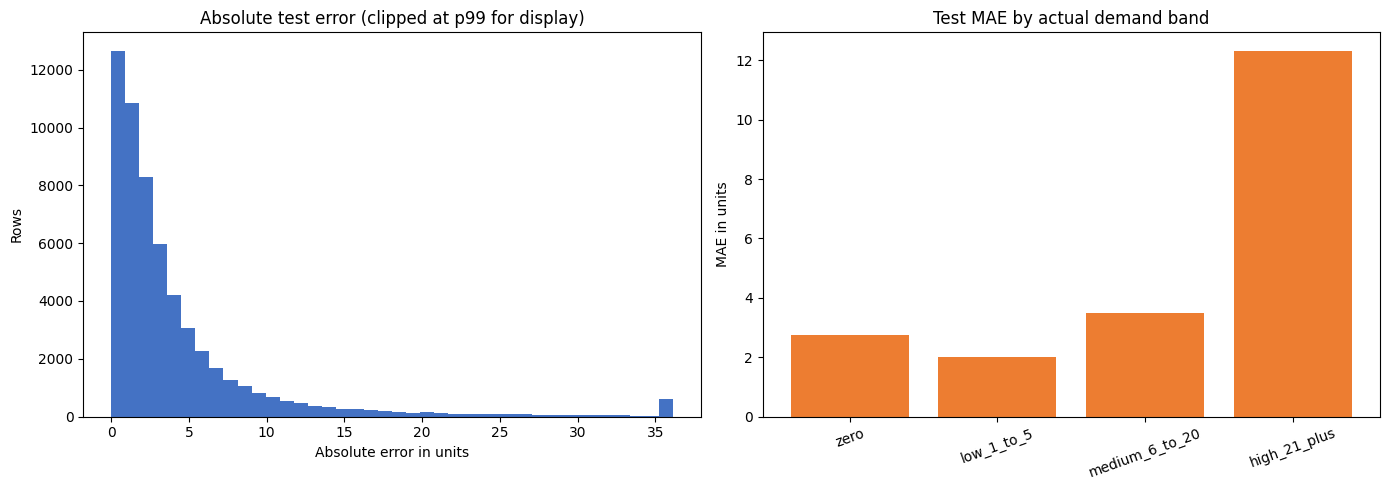

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(results["absolute_error"].clip(upper=results["absolute_error"].quantile(0.99)), bins=40, color="#4472C4")
axes[0].set_title("Absolute test error (clipped at p99 for display)")
axes[0].set_xlabel("Absolute error in units")
axes[0].set_ylabel("Rows")
axes[1].bar(demand_band_metrics["demand_band"].astype(str), demand_band_metrics["mae"], color="#ED7D31")
axes[1].set_title("Test MAE by actual demand band")
axes[1].set_ylabel("MAE in units")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. Conclusion

The final score is useful for weekly planning, but errors are not uniform. High-demand and unusual product-weeks require more caution, and predictions should support rather than replace inventory decisions. No model changes are made after this test analysis.